### **Define the State**

In [2]:
from typing import TypedDict

class ParentClass(TypedDict):
    usd_amount: float
    usd_total_amount: float
    bdt_total_amount: float

### **Node -> Convert usd amount to total usd amount with 12% extra**

In [3]:
def amount_to_totalAmount(state: ParentClass) -> ParentClass:
    state['usd_total_amount'] = state['usd_amount']*1.12
    return state

### **Node -> Convert usd amount to bdt amount with considering conversion rate 122 tk for 1 usd**

In [ ]:
def usd_bdt(state: ParentClass) -> ParentClass:
    state['bdt_total_amount'] = state['usd_total_amount']*1.22
    return state

### **Defining our GRAPH with its edges and nodes**

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ParentClass)

graph.add_node('Usd amount to total USD amount', amount_to_totalAmount)
graph.add_node('USD total amount to BDT total amount', usd_bdt)

graph.add_edge(START, 'Usd amount to total USD amount') #Usd_amount_to_total_usd_amount, USD_total_amount_to_BDT_total_amount
graph.add_edge('Usd amount to total USD amount', 'USD total amount to BDT total amount')
graph.add_edge('USD total amount to BDT total amount', END)

graph = graph.compile()

### **Draw the graph**

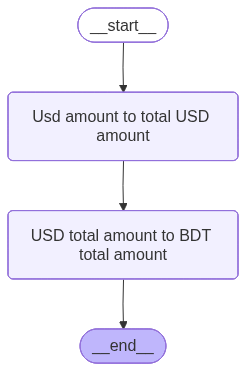

In [8]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### **Check how it works**

In [7]:
graph.invoke({"usd_amount": 1000})

{'usd_amount': 1000, 'usd_total_amount': 1120.0, 'bdt_total_amount': 1254.4}